# Titanic - Machine Learning from Disaster 🧠

## Importing necessary libraries

In [1]:
# Import libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


## Reading the datasets

In [3]:
train_data = pd.read_csv('/kaggle/input/titanic/train.csv')
test_data = pd.read_csv('/kaggle/input/titanic/test.csv')

## EDA

In [4]:
print(f"Train dataset has {train_data.shape[0]} rows and {train_data.shape[1]} columns.")
print(f"Test dataset has {test_data.shape[0]} rows and {test_data.shape[1]} columns.")

Train dataset has 891 rows and 12 columns.
Test dataset has 418 rows and 11 columns.


In [5]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
train_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [9]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
# Number of NaN value in each column
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
# Total number of NaN values
print(f"Total number of NaN values in train data: {train_data.isnull().sum().sum()}")

Total number of NaN values in train data: 866


<Axes: >

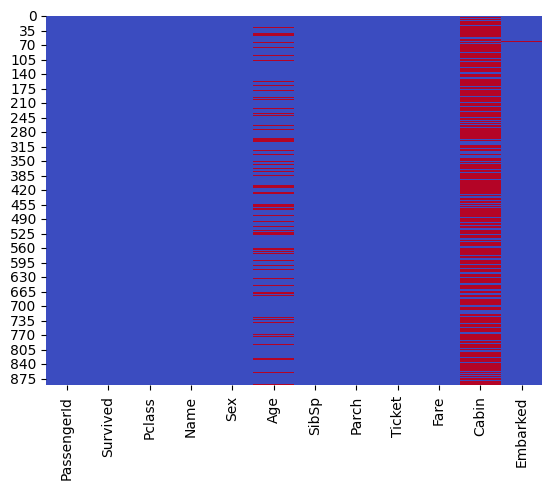

In [12]:
sns.heatmap(train_data.isnull(), cmap='coolwarm', cbar=False)

In [13]:
test_data.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [14]:
print(f"Total number of NaN values in test data: {test_data.isnull().sum().sum()}")

Total number of NaN values in test data: 414


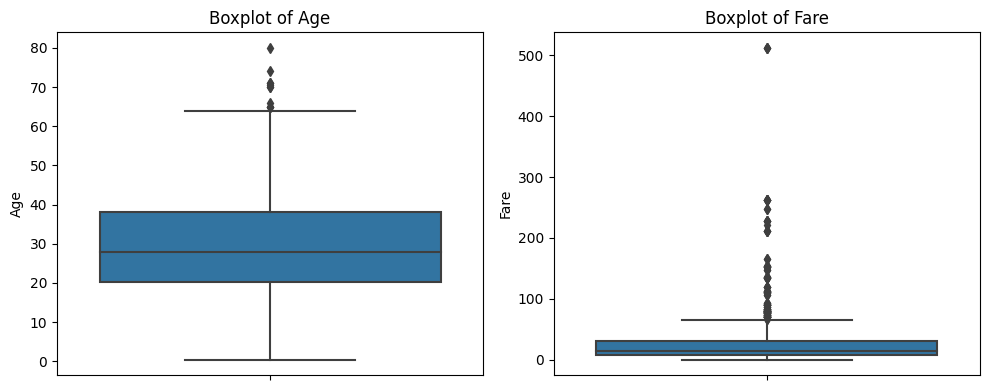

In [15]:
# Checking for exsiting outliers

plt.figure(figsize=(10, 4))

columns_to_plot = ['Age', 'Fare']

for i in range(len(train_data[columns_to_plot].columns)):
    plt.subplot(1, 2, i+1)
    sns.boxplot(y=train_data[columns_to_plot[i]], data = train_data)
    plt.title(f'Boxplot of {columns_to_plot[i]}')

plt.tight_layout()
plt.show()

## Data cleaning

In [16]:
# Drop unnecessary columns

columns_to_drop = ['Name', 'Ticket', 'Cabin', 'Embarked']
train_data.drop(columns=columns_to_drop, axis=1, inplace=True)
test_data.drop(columns=columns_to_drop, axis=1, inplace=True)

In [17]:
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,male,22.0,1,0,7.2500
1,2,1,1,female,38.0,1,0,71.2833
2,3,1,3,female,26.0,0,0,7.9250
3,4,1,1,female,35.0,1,0,53.1000
4,5,0,3,male,35.0,0,0,8.0500


In [18]:
test_data.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare
0,892,3,male,34.5,0,0,7.8292
1,893,3,female,47.0,1,0,7.0000
2,894,2,male,62.0,0,0,9.6875
3,895,3,male,27.0,0,0,8.6625
4,896,3,female,22.0,1,1,12.2875


In [19]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
train_data['Age'] = imputer.fit_transform(train_data[['Age']])
test_data['Age'] = imputer.fit_transform(test_data[['Age']])
test_data['Fare'] = imputer.fit_transform(test_data[['Fare']])

In [20]:
print(f"Total number of NaN values in train data: {train_data.isnull().sum().sum()}")
print(f"Total number of NaN values in test data: {test_data.isnull().sum().sum()}")

Total number of NaN values in train data: 0
Total number of NaN values in test data: 0


In [21]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
train_data['Sex'] = encoder.fit_transform(train_data['Sex'])
test_data['Sex'] = encoder.fit_transform(test_data['Sex'])

In [22]:
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,1,22.0,1,0,7.2500
1,2,1,1,0,38.0,1,0,71.2833
2,3,1,3,0,26.0,0,0,7.9250
3,4,1,1,0,35.0,1,0,53.1000
4,5,0,3,1,35.0,0,0,8.0500


In [23]:
test_data.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare
0,892,3,1,34.5,0,0,7.8292
1,893,3,0,47.0,1,0,7.0000
2,894,2,1,62.0,0,0,9.6875
3,895,3,1,27.0,0,0,8.6625
4,896,3,0,22.0,1,1,12.2875


In [24]:
# Create X and y 

X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

In [25]:
X.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,3,1,22.0,1,0,7.2500
1,2,1,0,38.0,1,0,71.2833
2,3,3,0,26.0,0,0,7.9250
3,4,1,0,35.0,1,0,53.1000
4,5,3,1,35.0,0,0,8.0500


In [26]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [27]:
# Feature scaling

from sklearn.preprocessing import RobustScaler

columns_to_scale = ['Age', 'Fare']

scaler = RobustScaler()
X[columns_to_scale] = scaler.fit_transform(X[columns_to_scale])
test_data[columns_to_scale] = scaler.fit_transform(test_data[columns_to_scale])

In [28]:
X[columns_to_scale].head()

,Age,Fare
0,-0.461538,-0.312011
1,0.769231,2.461242
2,-0.153846,-0.282777
3,0.538462,1.673732
4,0.538462,-0.277363


In [29]:
# Split the dataset into train and test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Create Random Forest Model

In [30]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100,
                               max_depth=10,
                               min_samples_split=2,
                               min_samples_leaf=1) 

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10)

In [31]:
# Predicting the model

train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

In [32]:
# Evaluating the model

from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy : {test_acc:.4f}")

Training Accuracy: 0.9424
Testing Accuracy : 0.8156


## Result of competiotion

In [33]:
predictions = model.predict(test_data)

submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': predictions
})

submission.to_csv("submission.csv", index=False)

In [34]:
submission.head(10)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [35]:
submission.shape

(418, 2)